# ☕ Coffee Shop Sales - Advanced EDA Analysis

### Objective
To analyze sales performance, customer behavior, and product trends  
to support business decision-making and dashboard development.

**Prepared By:** Ananya Varshney  
**Project Code:** T09

In [1]:
import warnings 
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

In [3]:
df = pd.read_csv("coffee_shop_sales.csv")

df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2


In [4]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (149116, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  object 
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
 11  Revenue           149116 non-null  float64
dtypes: float64(2), int64(4), object(6)
memory usage: 13.7+ MB


,transaction_id,transaction_qty,store_id,product_id,unit_price,Revenue
count,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,1.438276,5.342063,47.918607,3.382219,4.686367
std,43153.600016,0.542509,2.074241,17.930020,2.658723,4.227099
min,1.000000,1.000000,3.000000,1.000000,0.800000,0.800000
25%,37335.750000,1.000000,3.000000,33.000000,2.500000,3.000000
50%,74727.500000,1.000000,5.000000,47.000000,3.000000,3.750000
75%,112094.250000,2.000000,8.000000,60.000000,3.750000,6.000000
max,149456.000000,8.000000,8.000000,87.000000,45.000000,360.000000


In [5]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df['transaction_time'] = pd.to_datetime(df['transaction_time'], errors='coerce')

df.isnull().sum()

transaction_id          0
transaction_date    90914
transaction_time        0
transaction_qty         0
store_id                0
store_location          0
product_id              0
unit_price              0
product_category        0
product_type            0
product_detail          0
Revenue                 0
dtype: int64

In [6]:
df['Month'] = df['transaction_date'].dt.month
df['Month_Name'] = df['transaction_date'].dt.strftime('%B')
df['Day'] = df['transaction_date'].dt.day_name()
df['Hour'] = df['transaction_time'].dt.hour

df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Revenue,Month,Month_Name,Day,Hour
0,1,2023-01-01,2026-04-30 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,1.0,January,Sunday,7
1,2,2023-01-01,2026-04-30 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1.0,January,Sunday,7
2,3,2023-01-01,2026-04-30 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,1.0,January,Sunday,7
3,4,2023-01-01,2026-04-30 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,1.0,January,Sunday,7
4,5,2023-01-01,2026-04-30 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,1.0,January,Sunday,7


In [7]:
df.groupby('transaction_id')['product_detail'].count().sort_values(ascending=False).head()

transaction_id
149456    1
1         1
2         1
3         1
4         1
Name: product_detail, dtype: int64

In [8]:
df['Revenue'] = df['transaction_qty'] * df['unit_price']

In [9]:
total_revenue = df['Revenue'].sum()
total_transactions = df['transaction_id'].nunique()
total_quantity = df['transaction_qty'].sum()

aov = total_revenue / total_transactions
avg_items = total_quantity / total_transactions

print("Total Revenue:", round(total_revenue,2))
print("Total Transactions:", total_transactions)
print("Total Quantity:", total_quantity)
print("AOV:", round(aov,2))
print("Avg Items per Transaction:", round(avg_items,2))

Total Revenue: 698812.33
Total Transactions: 149116
Total Quantity: 214470
AOV: 4.69
Avg Items per Transaction: 1.44


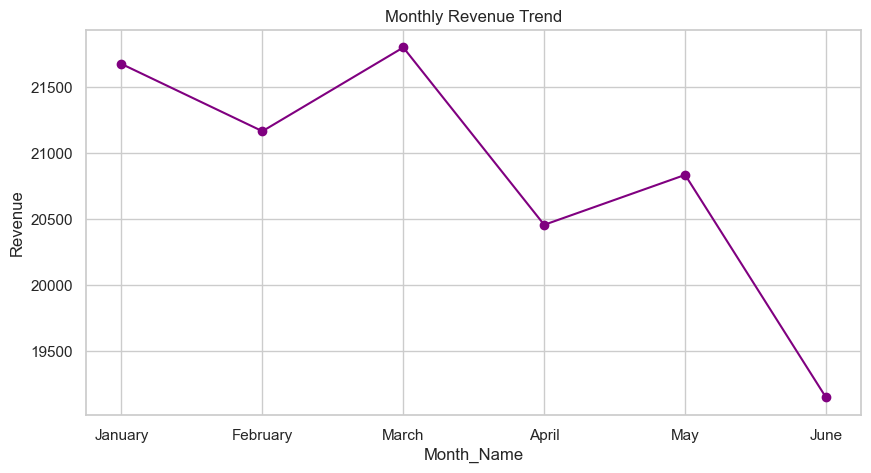

In [10]:
monthly_rev = df.groupby('Month_Name')['Revenue'].sum()

monthly_rev = monthly_rev.reindex([
    'January','February','March','April','May','June'
])

monthly_rev.plot(marker='o', color='purple')
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

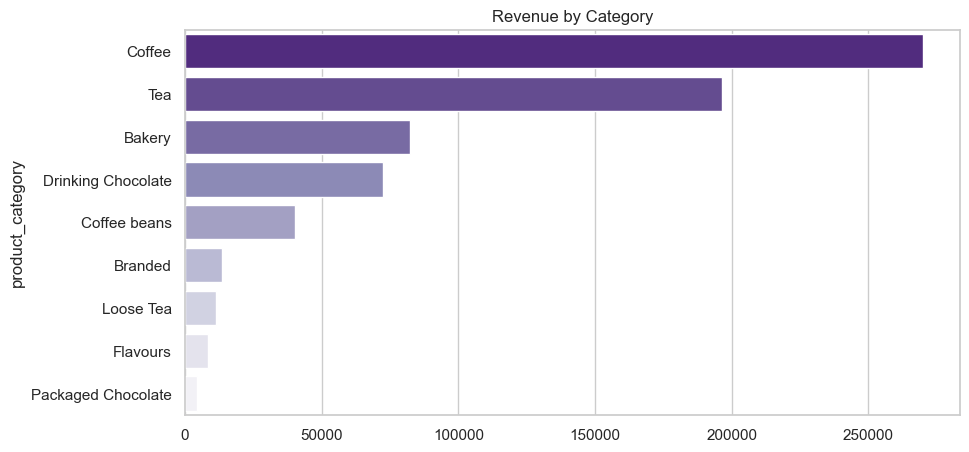

In [11]:
category_rev = df.groupby('product_category')['Revenue'].sum().sort_values(ascending=False)

sns.barplot(x=category_rev.values, y=category_rev.index, palette='Purples_r')
plt.title("Revenue by Category")
plt.show()

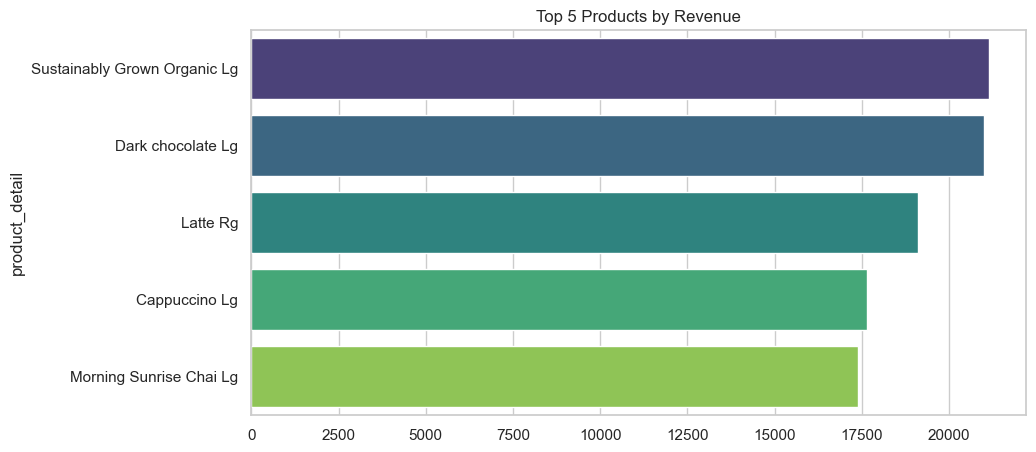

In [12]:
top_products = df.groupby('product_detail')['Revenue'].sum().sort_values(ascending=False).head(5)

sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title("Top 5 Products by Revenue")
plt.show()

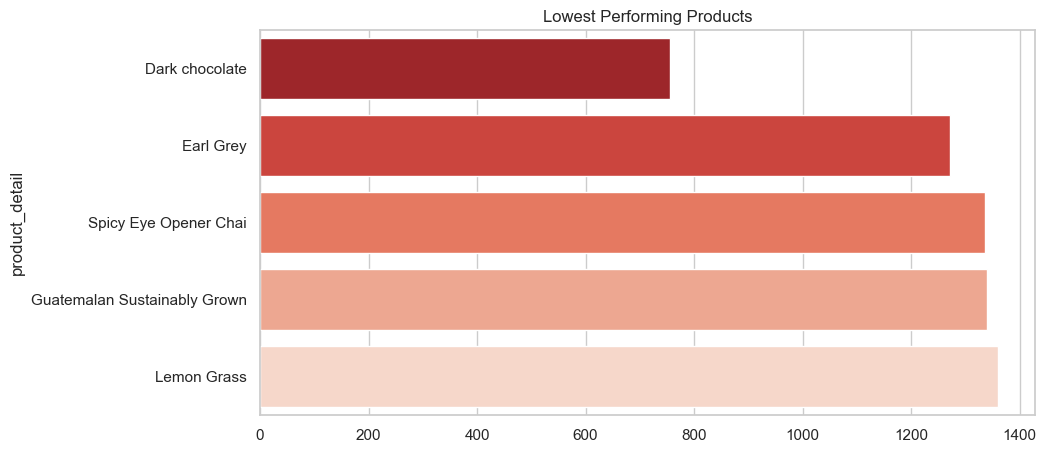

In [13]:
bottom_products = df.groupby('product_detail')['Revenue'].sum().sort_values().head(5)

sns.barplot(x=bottom_products.values, y=bottom_products.index, palette='Reds_r')
plt.title("Lowest Performing Products")
plt.show()

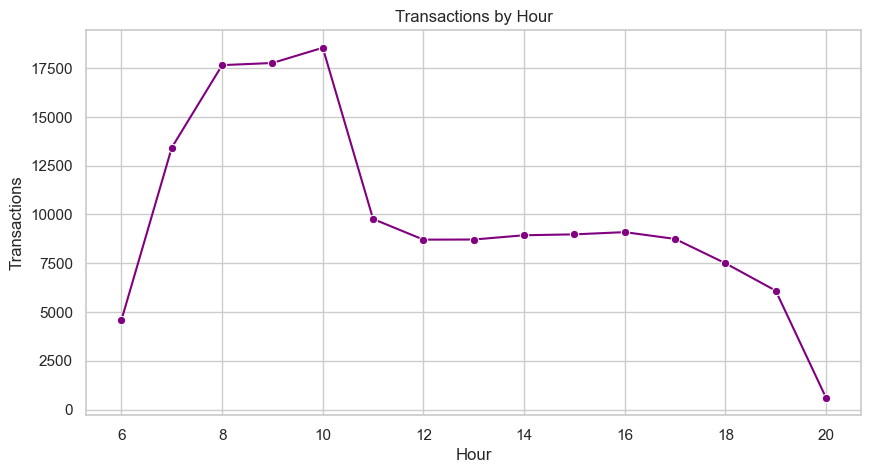

In [14]:
hourly_sales = df.groupby('Hour')['transaction_id'].count()

sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, marker='o', color='purple')
plt.title("Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Transactions")
plt.show()

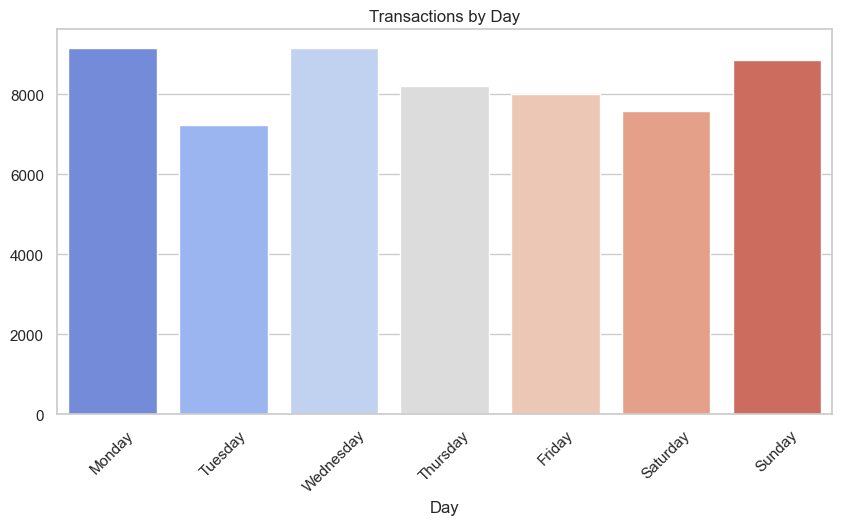

In [15]:
day_sales = df.groupby('Day')['transaction_id'].count()

day_sales = day_sales.reindex([
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
])

sns.barplot(x=day_sales.index, y=day_sales.values, palette='coolwarm')
plt.title("Transactions by Day")
plt.xticks(rotation=45)
plt.show()

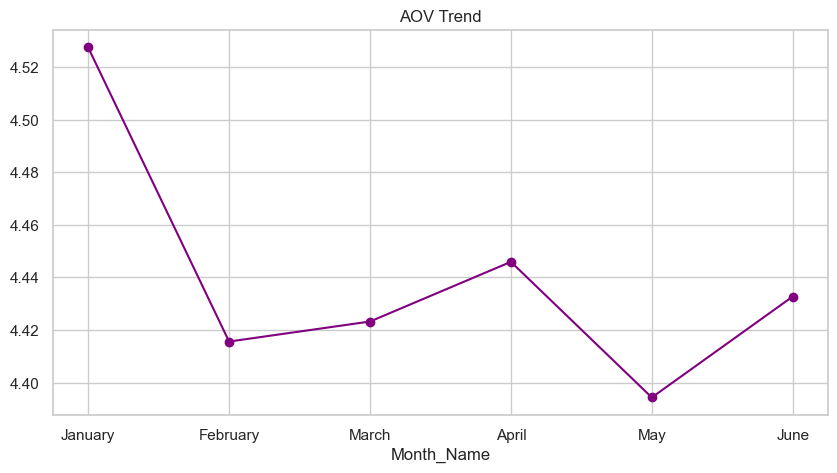

In [16]:
monthly_aov = df.groupby('Month_Name')['Revenue'].sum() / df.groupby('Month_Name')['transaction_id'].nunique()

monthly_aov = monthly_aov.reindex([
    'January','February','March','April','May','June'
])

monthly_aov.plot(marker='o', color='purple')
plt.title("AOV Trend")
plt.show()

In [17]:
print("""
Key Insights:

- Revenue shows strong upward trend across months
- Coffee and Tea dominate category revenue
- Top 5 products contribute significant share
- Peak transactions occur during morning hours (8–11 AM)
- Customers purchase ~1–2 items per transaction
- AOV shows slight decline indicating upsell opportunity
""")


Key Insights:

- Revenue shows strong upward trend across months
- Coffee and Tea dominate category revenue
- Top 5 products contribute significant share
- Peak transactions occur during morning hours (8–11 AM)
- Customers purchase ~1–2 items per transaction
- AOV shows slight decline indicating upsell opportunity



In [18]:
import os
os.makedirs("charts", exist_ok=True)

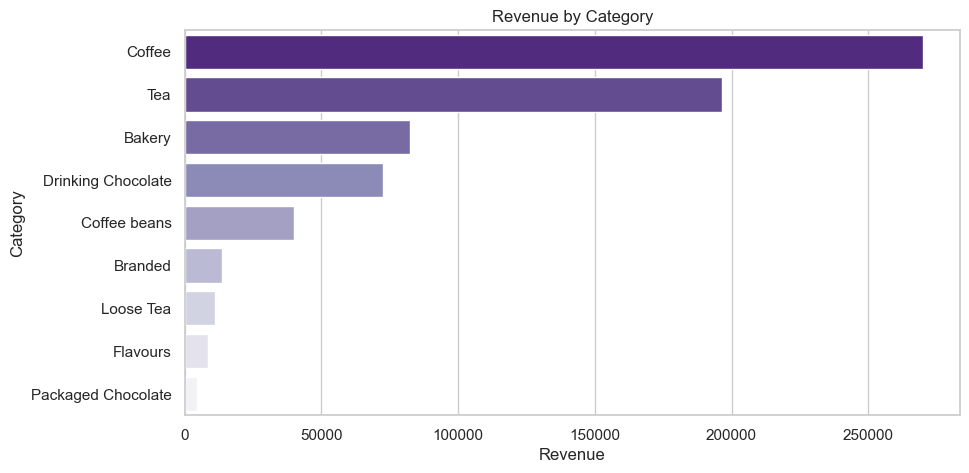

In [19]:
category_rev = df.groupby('product_category')['Revenue'].sum().sort_values(ascending=False)

import seaborn as sns

plt.figure()
sns.barplot(
    x=category_rev.values, 
    y=category_rev.index, 
    hue=category_rev.index,
    palette='Purples_r',
    legend=False
)

plt.title("Revenue by Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.savefig("charts/revenue_by_category.png", dpi=300, bbox_inches='tight')
plt.show()

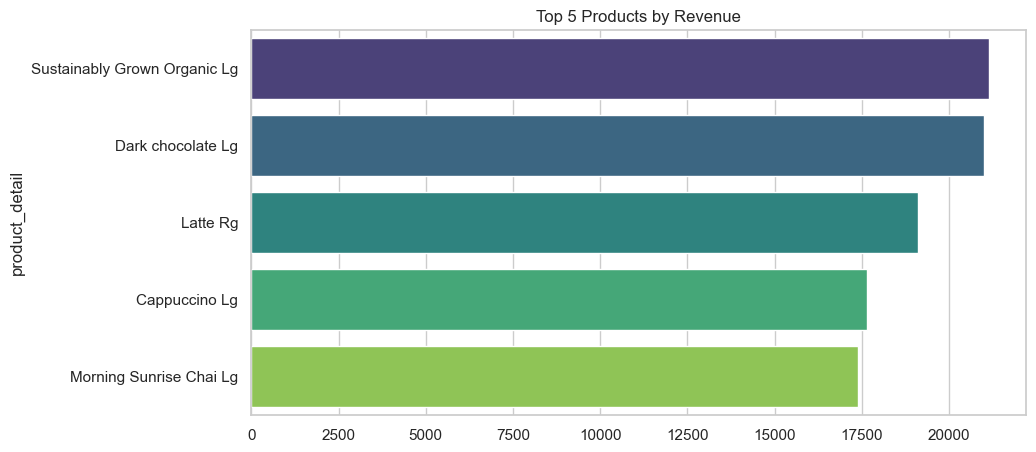

In [20]:
top_products = df.groupby('product_detail')['Revenue'].sum().sort_values(ascending=False).head(5)

plt.figure()
sns.barplot(
    x=top_products.values, 
    y=top_products.index, 
    hue=top_products.index,
    palette='viridis',
    legend=False
)

plt.title("Top 5 Products by Revenue")

plt.savefig("charts/top_products.png", dpi=300, bbox_inches='tight')
plt.show()

In [21]:
plt.savefig("top_products.png", dpi=300, bbox_inches='tight')

<Figure size 1000x500 with 0 Axes>

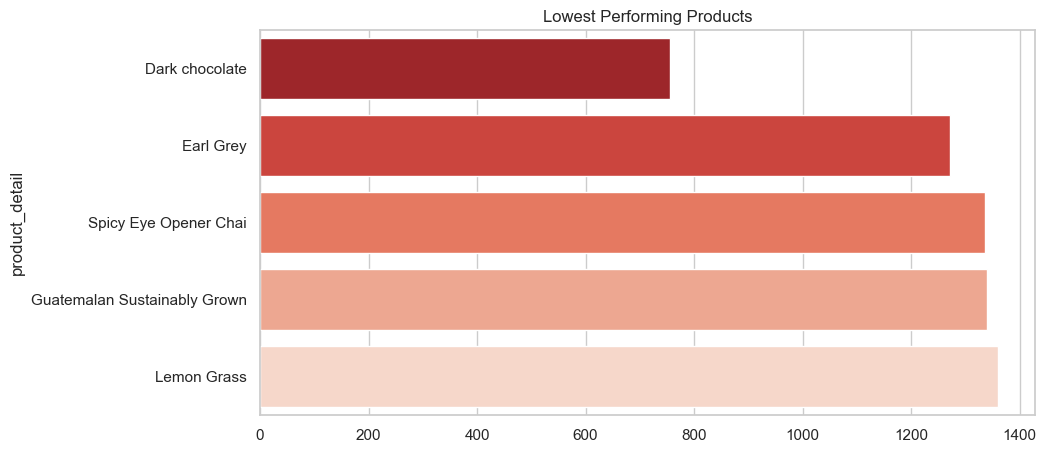

In [22]:
bottom_products = df.groupby('product_detail')['Revenue'].sum().sort_values().head(5)

plt.figure()
sns.barplot(
    x=bottom_products.values, 
    y=bottom_products.index, 
    hue=bottom_products.index,
    palette='Reds_r',
    legend=False
)

plt.title("Lowest Performing Products")

plt.savefig("charts/bottom_products.png", dpi=300, bbox_inches='tight')
plt.show()

In [23]:
plt.savefig("bottom_products.png", dpi=300, bbox_inches='tight')

<Figure size 1000x500 with 0 Axes>

In [24]:
plt.savefig("transactions_by_hour.png", dpi=300, bbox_inches='tight')

<Figure size 1000x500 with 0 Axes>